# Classificação de flores Iris com MLP

## 1. Data load

In [5]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

I0000 00:00:1787601539.041159   51285 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787601539.067658   51285 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [6]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [7]:
iris = load_iris()
attributes = iris.data
species = iris.target

In [8]:
display(pd.DataFrame(attributes, columns=iris.feature_names).head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### 1.1. Data Distribution

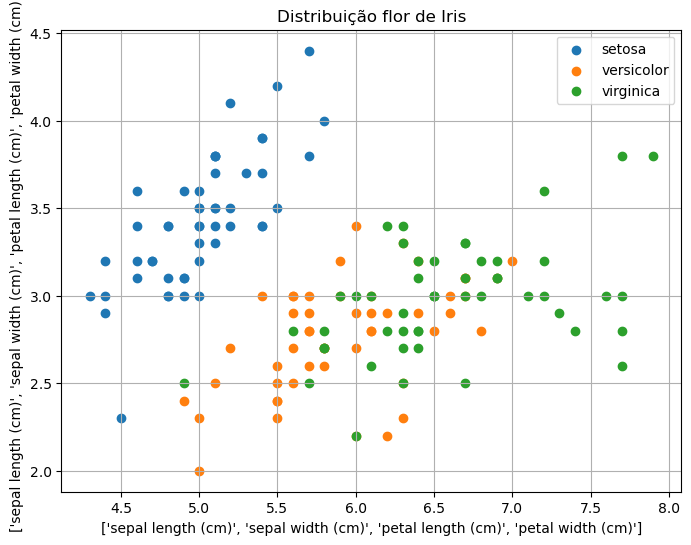

In [10]:
plt.figure(figsize=(8,6))
for i, target_name in enumerate(iris.target_names):
    plt.scatter(attributes[species == i, 0], attributes[species == i, 1], label=target_name)

plt.title("Distribuição flor de Iris")
plt.xlabel(iris.feature_names)
plt.ylabel(iris.feature_names)
plt.legend()
plt.grid(True)
plt.show()


### 1.2. One-Hot Encoding

In [11]:
encoder = OneHotEncoder(sparse_output=False)
species_encoded = encoder.fit_transform(species.reshape(-1, 1))

print("Exemplo de espécies codificas: ")
print(species_encoded[:5])

Exemplo de espécies codificas: 
[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


### 1.3. Data Split

In [12]:
attr_train, attr_test, spec_train, spec_test = train_test_split(attributes, species_encoded, test_size=0.2, random_state=42)

### 1.4 normalization

In [13]:
normalizer = StandardScaler()
attr_train = normalizer.fit_transform(attr_train)
attr_test = normalizer.transform(attr_test)

## 2. Model and Train

In [14]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(4,)),
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(3, activation="softmax")
])

I0000 00:00:1787602026.290338   51285 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5803 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


In [17]:
opt = tf.optimizers.Adam(learning_rate=0.01)
model.compile(optimizer="Adam", loss="categorical_crossentropy", metrics=["accuracy"])

history = model.fit(attr_train, spec_train, epochs=100, batch_size=5, validation_split=0.1, verbose=0)

I0000 00:00:1787603213.070124   53259 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_9702__.16
I0000 00:00:1787603213.540643   53259 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_9702__.16


## 3. Results

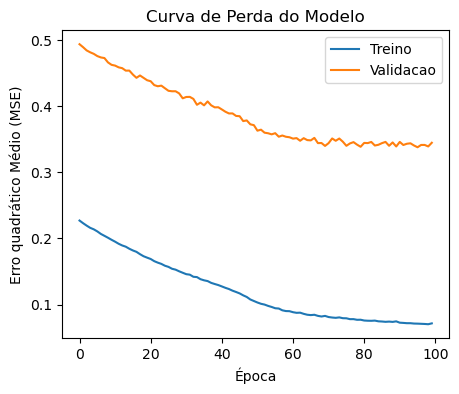

In [18]:
plt.figure(figsize=(5, 4))
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Curva de Perda do Modelo")
plt.ylabel("Erro quadrático Médio (MSE)")
plt.xlabel("Época")
plt.legend(["Treino", "Validacao"])